# Introduction to Audio and Music Processing (CH-EAM-B)
# 02 - Fundamentals of Acoustics

Prof. Dr. Jakob Abeßer (jakob.abesser@uni-bamberg.de)

Last update: 27.04.2026

## Learning Objectives

1. Use the **pyroomacoustics** Python library to define a room acoustic model with room size, absorption coefficient, and microphone/loudspeaker placement.
2. Use convolution to simulate reverberation to specific audio signals.

In [2]:
!pip install wget
!pip install pyroomacoustics
!pip install audiomentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.1/35.1 MB 42.6 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached Cython-3.0.12-cp37-cp37m-macosx_10_9_x86_64.whl.metadata (3.3 kB)
  Using cached pybind11-2.13.6-py3-none-any.whl.metadata (9.5 kB)
Using cached pybind11-2.13.6-py3-none-any.whl (243 kB)
Using cached Cython-3.0.12-cp37-cp37m-macosx_10_9_x86_64.whl (3.0 MB)
  Created wheel for pyroomacoustics: filename=pyroomacoustics-0.10.0-cp37-cp37m-macosx_10_9_x86_64.whl size=34537230 sha256=db5e03bc63e6f85f7ca985edfcdf4ca2e892b8cb60692700c09bda14d4d3a3e6
  Stored in directory: /Users/jakobabeer/Library/Caches/pip/wheels/75/6a/5a/ba12b5468043a4158145ff22cf868e4e3dfe565dfcee3bac50
Successfully built pyroomacoustics


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import wget
import zipfile
import os

import librosa
import librosa.display
import soundfile as sf
import pyroomacoustics as pra
from audiomentations import Compose, AddBackgroundNoise, ApplyImpulseResponse, LowPassFilter

from pathlib import Path
from IPython.display import Audio, display, Markdown

In [5]:
fn_list = ['podcast_voice_short.wav',
           'acc_guitar_arp.wav']

# download zip file (if it has been downloaded already)
if not os.path.isfile('CH-EAM-B-Seminar-02_sounds.zip'):
    print('Please wait a couple of seconds ...')
    wget.download('https://github.com/CHBamberg/CH-EAM-B-SS-2026/raw/refs/heads/main/data/CH-EAM-B-Seminar-02_sounds.zip', 
                      out='CH-EAM-B-Seminar-02_sounds.zip', bar=None)
    print('CH-EAM-B-Seminar-02_sounds.zip downloaded successfully ...')
else:
    print('Files already exist!')

# if at least one of the audio files does not exist -> unzip zip file
if any([not os.path.isfile(_) for _ in fn_list]):
    print("Let's unzip the file ... ")
    assert os.path.isfile('CH-EAM-B-Seminar-02_sounds.zip')
    with zipfile.ZipFile('CH-EAM-B-Seminar-02_sounds.zip', 'r') as f:
        f.extractall('.')
        
    assert all([os.path.isfile(_) for _ in fn_list])
    print("All done :)")
else:
    print('All audio files exist.')

Please wait a couple of seconds ...
CH-EAM-B-Seminar-02_sounds.zip downloaded successfully ...
Let's unzip the file ... 
All done :)


## Helper Functions

In [6]:
def show_audio(y, sr, label=None):
    """ Show playback button to listen to audio file
    Args:
        y (np.ndarray): Audio samples
        sr (float): Sample rate (in Hz)
        label (str): Optional label
    """
    if label is not None:
        display(Markdown(f"**{label}**"))
    display(Audio(y, rate=sr, normalize=False))
    
def plot_waveform(y, sr, start_s=0.0, end_s=None, title="Waveform"):
    """ Plot waveform of audio recording or a segment thereof
    Args:
        y (np.ndarray): Audio samples
        sr (float): Sample rate (in Hz)
        start_s (float): Segement start (in s)
        end_s (float): Segment end (in s), if None: end of the file is used
        title (str): optional figure title
    """
    start = int(start_s * sr)
    end = len(y) if end_s is None else int(end_s * sr)
    end = min(end, len(y))
    start = max(0, start)

    t = np.arange(start, end) / sr

    plt.figure(figsize=(12, 3))
    plt.plot(t, y[start:end], linewidth=1)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.tight_layout()
    plt.show()

## Audio Material

- **podcast_voice_short.wav** - vocal sample from https://freesound.org/people/qubodup/sounds/842832/
(beginning of 842832__qubodup__podcast-ai-slop.ogg) 
- **acc_guitar_arp.wav** - acoustic guitar sample from 
https://freesound.org/people/ajubamusic/sounds/320800/ (beginning of 320800__ajubamusic__acoustic-picking-guitar-100bpm-key-of-c.mp3)

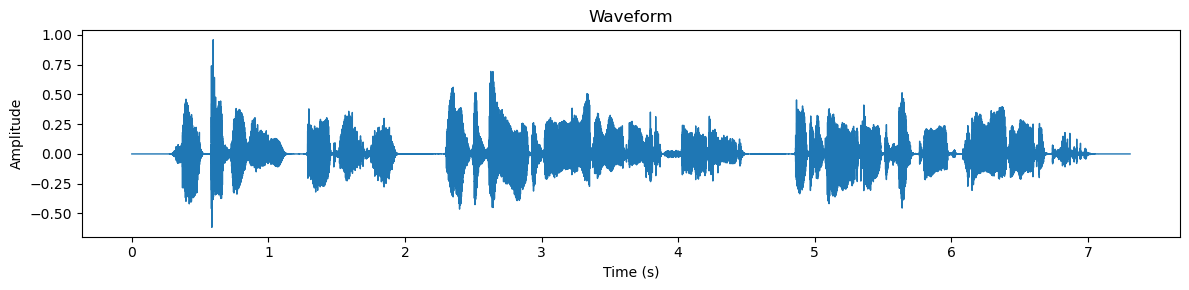

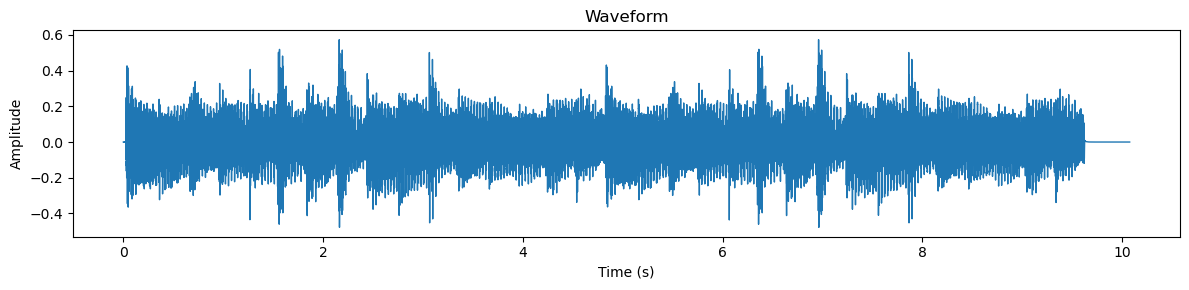

In [10]:
# Let's listen to the audio files
for fn_wav in fn_list:
    x, fs = librosa.load(fn_wav)
    plot_waveform(x, fs)
    show_audio(x, fs)

## 1) Room simulation and reflections

In [11]:
# TASK 1a Define room dimensions (meters) and absorption coefficient to be 
# - width = 5m, length = 4m, height = 3m
# - alpha = 0.2 (remember: 0 = fully reflective, 1 = fully absorbing / Anachoic chamber)
room_dim = [5, 4, 3]  # Width, Length, Height
absorption = 0.2      # 0 = fully reflective, 1 = fully absorbing (Anechoic) [cite: 18]

# TASK 1b use the pyroomacoustic package and create a "shoebox" room
#  hint: use a sample rate of 16 kHz, abd a "max_order" of 10
room = pra.ShoeBox(room_dim, fs=16000, materials=pra.Material(absorption), max_order=10)

# Now we need a sound source (loudspeaker) and a receiver (microphone)
# Place a source and a receiver (microphone) [cite: 13, 14]
# TASK 1c place the loudspeaker to the coordinates [2.5, 2, 1.5]
#  - hint: use "add_source()"
# TASK 1d place the microphone at [[3.5], [2], [1.5]]
#  - hint: use "add_microphone_array(pra.MicrophoneArray(...))"

room.add_source([2.5, 2, 1.5])
room.add_microphone_array(pra.MicrophoneArray(np.array([[3.5], [2], [1.5]]), room.fs))

# TASK 1e: compute the impulse response and plot it
# TASK 1f: identify the direct sound and the reflections in the IR plot
room.compute_rir()
rir = room.rir[0][0]

# Student Task: Plot the RIR and identify the Direct Sound vs. Reflections [cite: 21, 25]
plt.figure(figsize=(10, 4))
plt.plot(rir)
plt.title(f"Room Impulse Response (Absorption α = {absorption})")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

NameError: name 'pra' is not defined

## 2) Modeling the Room as an LTI System (Convolution)

In [ ]:
# TASK 2a: load the speech example as "dry" audio sample
y_dry, sr = librosa.load('podcast_voice_short.wav')

# TASK 2b: Convolve the audio samples of the dry signals with the RIR generated
# above
y_reverb = np.convolve(y_dry, rir)

# TASK 2c: Show waveforms of dry and reverberant signal and make sounds playable
print("Original 'Dry' Audio:")
display(Audio(y_dry, rate=sr))

# TASK 2d: Compare both

print("Simulated 'Wet' Audio (Convolved with Room):")
display(Audio(y_reverb, rate=sr))

## 3) Playground

Try the following modifications, explain your observations.

In [12]:
# TASK 3a: Make the room larger and smaller, how does the RIR change?

# TASK 3b: What happens if we increase / decrease the absorption coefficient?

# TASK 3c: Repeat 2 with the guitar recording

Done :)